In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.datasets import make_moons
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [2]:
target = ['activity']

X_train = pd.read_csv('samsung_train.txt', delim_whitespace=True, header=None)
X_train.columns = pd.read_csv('features.txt', delim_whitespace=True, header=None)[1]
y_train = pd.read_csv('samsung_train_labels.txt', header=None, names=target)

X_test = pd.read_csv('samsung_test.txt', delim_whitespace=True, header=None)
X_test.columns = pd.read_csv('features.txt', delim_whitespace=True, header=None)[1]
y_test = pd.read_csv('samsung_test_labels.txt', header=None, names=target)

#Łączymy dane X treningowe i testowe w jeden zbiór X i tak samo robimy z y.
X = pd.concat([X_train, X_test], axis=0)
y = pd.concat([y_train, y_test], axis=0)

C:\Users\marci\AppData\Local\Temp\ipykernel_27340\3441806120.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv('samsung_train.txt', delim_whitespace=True, header=None)
C:\Users\marci\AppData\Local\Temp\ipykernel_27340\3441806120.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train.columns = pd.read_csv('features.txt', delim_whitespace=True, header=None)[1]
C:\Users\marci\AppData\Local\Temp\ipykernel_27340\3441806120.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv('samsung_test.txt', delim_whitespace=True, header=None)
C:\Users\marci\AppData\Local\Temp\ipykernel_27340\3441806120.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_cs

**Przygotowanie danych:**

1. Czy potrzeba wszystkich cech?
**ODP: Domyślnie zakładamy, że wszystkie cechy są istotne. Jednak jeśli chcielibyśmy to zweryfikować to musielibyśmy stworzyć macierz 561 x 561 z funkcją corr (współczynnik korelacja Pearsona), czyli zbadać korelację danych każda z każdą, aby móc stwierdzić które nasze cechy mocno korelują. Jeśli wystąpiłyby takie przypadki, wtedy możemy ocenić czy pozostawić wszystkie cechy, czy może zredukować te które ze sobą korelują. W związku z tym pozostawimy bazę wszystkich cech oraz za pomocą PCA wyodrębnimy dwie główne składowe które posłużą nam do łatwego obrazowania efektów klasteryzacji na wykresach 2D**

2. Czy potrzebna jest jakaś obróbka? **ODP: Zgonie z informacją dane są znormalizowane [-1,1], jednak to nie to samo co standaryzacja gdzie średnia to 0, a std to 1. W związku z tym wystandaryzujemy dane w zbiorze treningowym.**

3. Czy wiemy, jak obrobić? **ODP: Tak, dokonamy standaryzacji - [KROK PIERWSZY], następnie dokonamy redukcji wymiarów do dwóch głównych składowych [KROK DRUGI] - ale tylko po to, jak wspomniano w punkcie pierwszych - aby można w sposób łatwy obrazować wyniki klasteryzacji na wykresach 2D**

4. Czy wiemy, co jaka cecha znaczy? **ODP: Tak. Dane surowe pochodzą z dwóch urządzeń, tą to dane trójosiowe z akcelerometra i żyroskopu. Dane zarejestrowane z częstotliwością 50 Hz a następnie został przefiltrowane celem usunięcia szumów - okno czasowe to 2,56 s. W zbiorze cech znajduje się 17 cech z których określono zmienne typu mean(), std () itd oraz dodatkowe wektory - angle(). Dane są wynikiem eksperymentu w którym wzięło 30 uczestników, którzy rejestrowali 6 różnych aktywności.**

5. Czy podział na dane testowe i treningowe jest potrzebny, jeśli tak to dlaczego, jeśli nie to dlaczego? **ODP: Podział danych na testowy i treningowy nie jest potrzebny w klasteryzacji. Zbiory treningowe i testowe to domena uczenia nadzorowanego, jeśli chodzi o klasteryzację to warto mieć jeden zbiór X - zawierający wartości niezależne.**

**[KROK PIERWSZY] - skalujemy dane w zbiorze X**

In [3]:
scaler = StandardScaler()

X_scaled =  scaler.fit_transform(X)

**[DRUGI KROK] - dokonujemy redukcji wymiarów zbioru X_scaled metodą PCA do dwóch głównych składowych, tak aby możliwa była wizualizacja klasteryzacji 2D**

In [4]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

**Wizualizujemy wyjaśnoną wariancję i skumulowaną wyjaśnioną wariancję dla dwóch pierwszych składowych oraz wyliczamy ich wartości**

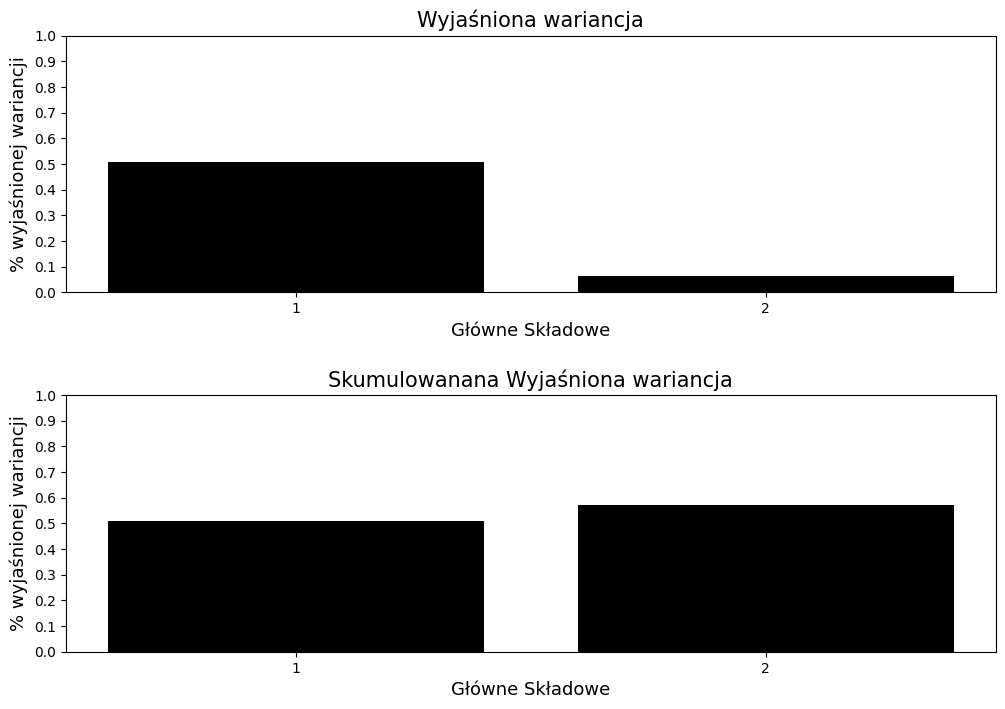

Główna składowa: 1, Wyjaśniona wariancja: 0.50738, Skumulowana Wyjaśniona wariancja: 0.50738
Główna składowa: 2, Wyjaśniona wariancja: 0.06239, Skumulowana Wyjaśniona wariancja: 0.56977


In [5]:
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(wspace=.4, hspace=.4)
ax = fig.add_subplot(2, 1, 1)
ax.bar(range(1, 1+pca.n_components_), pca.explained_variance_ratio_, color='black')
ax.set(xticks=[1, 2])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.title('Wyjaśniona wariancja', fontsize=15)
plt.xlabel('Główne Składowe', fontsize=13)
plt.ylabel('% wyjaśnionej wariancji', fontsize=13)
ax = fig.add_subplot(2, 1, 2)
ax.bar(range(1, 1+pca.n_components_), np.cumsum(pca.explained_variance_ratio_), color='black')
ax.set(xticks=[1, 2])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.title('Skumulowanana Wyjaśniona wariancja', fontsize=15)
plt.xlabel('Główne Składowe', fontsize=13)
plt.ylabel('% wyjaśnionej wariancji', fontsize=13)
plt.show()

principal_component = 1
cum_explained_var = 0
for explained_var in pca.explained_variance_ratio_:
    cum_explained_var += explained_var
    print(f'Główna składowa: {principal_component}, Wyjaśniona wariancja: {np.round(explained_var, 5)}, Skumulowana Wyjaśniona wariancja: {np.round(cum_explained_var, 5)}')
    principal_component += 1

In [6]:
print(f'KOMENTARZ: dwie pierwsze składowe wyjaśniają wariancję w {np.round((cum_explained_var*100),2)} % - jest to dość słaby wynik.')

KOMENTARZ: dwie pierwsze składowe wyjaśniają wariancję w 56.98 % - jest to dość słaby wynik.


**Definiujemy funkcje do wizualizacji wyników klasteryzacji**

In [7]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=3, linewidths=8,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(klasyfikator, X, show=False):
    # wyznaczanie granic decyzyjnych, podobnie jak w poprzednich notatnikach
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], 100),
                         np.linspace(mins[1], maxs[1], 100))
    Z = klasyfikator.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # rysowanie konturów granic 
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    
    # rysowanie danych
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    # centra klastrów można wyciągnąc za pomocą zmiennej cluster_centers_
    plot_centroids(klasyfikator.cluster_centers_)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)
    

#Specjalna funkcja z bardzo małym parametrem alpha=0.05, aby móc czytelnie połączyć wykresy aktywności z wynikiem klastryzacji
def plot_decision_boundaries_alpha_005(klasyfikator, X, show=False):
    # wyznaczanie granic decyzyjnych, podobnie jak w poprzednich notatnikach
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], 100),
                         np.linspace(mins[1], maxs[1], 100))
    Z = klasyfikator.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # rysowanie konturów granic 
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    
    # rysowanie danych
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2, alpha=0.05)
    # centra klastrów można wyciągnąc za pomocą zmiennej cluster_centers_
    plot_centroids(klasyfikator.cluster_centers_)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)
    
    
def plot_dbscan(dbscan, X, size):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]
    
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)
    

def plot_gaussian_mixture(clf, X, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clf.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, linewidths=3, colors='b')
    
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

    plt.xlabel("$x_1$", fontsize=14)
    plt.tick_params(labelleft=False)

**[KMEANS] - dokonajmy klasteryzacji za pomocą modelu - KMeans z parametrem n-clusters = 6**

In [8]:
clf_kmeans = KMeans(n_clusters=6)
clf_kmeans.fit(X_pca)

KMeans(n_clusters=6)

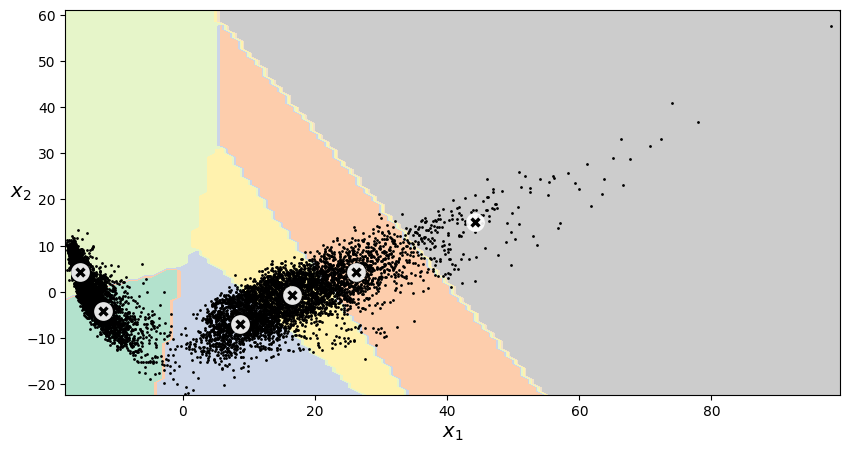

In [9]:
plt.figure(figsize=(10, 5))
plot_decision_boundaries(clf_kmeans, X_pca)
plt.show()

**KOMENTARZ: W mojej opinii na wykresie widać w sumie tylko dwa zbiory, natomiast 6 klastrów znalezionych przez KMeans nie obrazuje stanu faktycznego.**

**Sprawdźmy jeszcze jak poradzą sobie inne modele klasteryzacyjne (DBSCAN i GMM):**

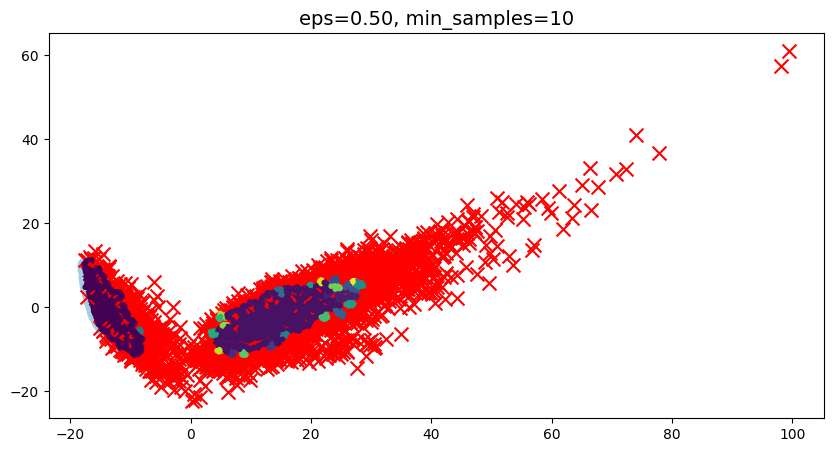

In [10]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan.fit(X_pca)

plt.figure(figsize=(10, 5))
plot_dbscan(dbscan, X_pca, size=100)
plt.show()

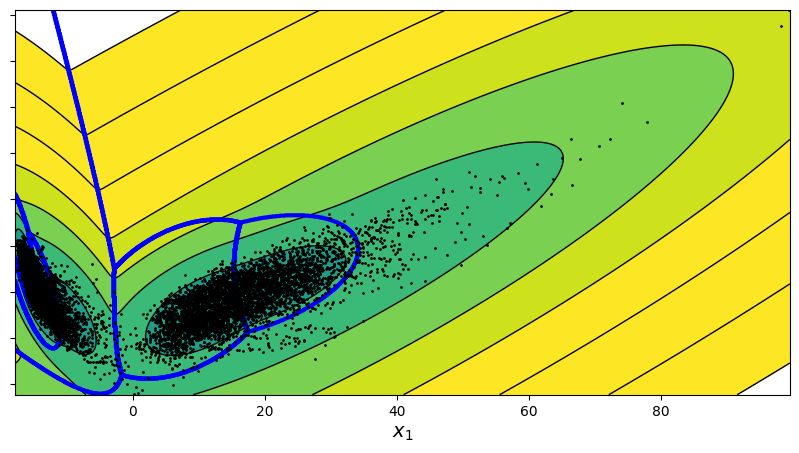

In [11]:
gmm = GaussianMixture(n_components=6, n_init=100)
gmm.fit(X_pca)

plt.figure(figsize=(10, 5))
plot_gaussian_mixture(gmm, X_pca)
plt.show()

**[PYTANIE] Z jakim typem czynności algorytmy poradziły sobie super, z jakim nie najlepiej. Typy czynności (dane zawarte w plikach *labels):**

1 - marsz, 
2 - wchodzenie w górę po schodach, 
3 – schodzenie w dół ze schodów, 
4 – siedzenie, 
5 – stanie, 
6 – leżenie.

**[KOMENTARZ] Aby odpowiedzieć na to pytanie należy zwizualizować dane na wykresie z podziałem na w/w czynności wg. labels, a następnie skonfrontować to z wynikami klasteryzacji KMeans - wszystko na bazie głównych składowych PC1 i PC2**

**Tworzymy wizualizację na wykresie według w/w czynności**

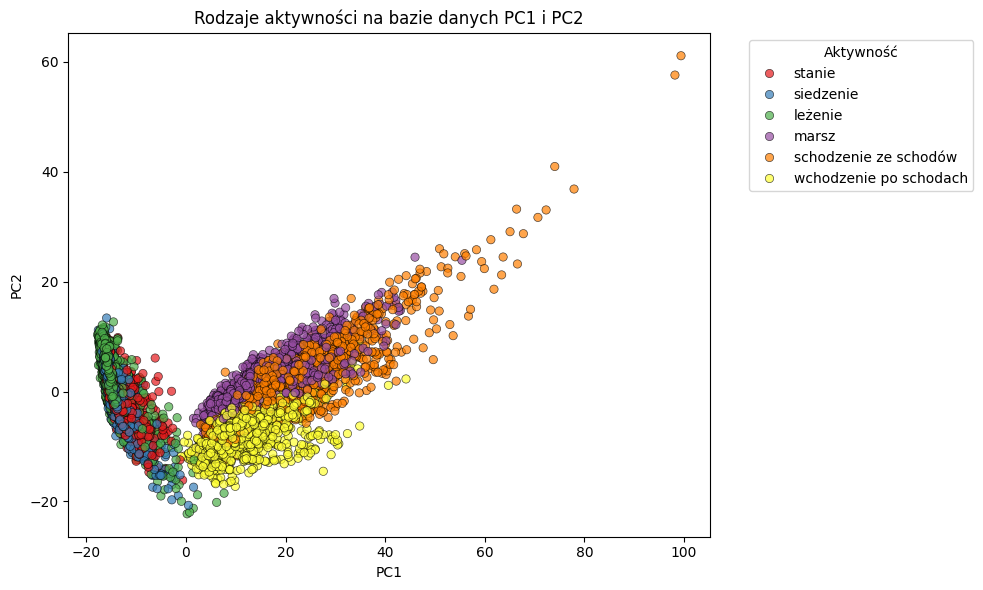

In [12]:
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
datasets_pca = pd.concat([X_pca_df.reset_index(drop=True), y.reset_index(drop=True)], axis=1)

activity_labels = {
    1: 'marsz',
    2: 'wchodzenie po schodach',
    3: 'schodzenie ze schodów',
    4: 'siedzenie',
    5: 'stanie',
    6: 'leżenie'
}

df_plot = datasets_pca.copy()
df_plot['activity_label'] = df_plot['activity'].map(activity_labels)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='PC1', y='PC2',
    hue='activity_label',
    palette='Set1',
    alpha=0.7,
    edgecolor='k'
)

plt.title('Rodzaje aktywności na bazie danych PC1 i PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Aktywność', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Tworzymy wykres na którym porównamy wykres aktywności z klasteryzacją KMeans**

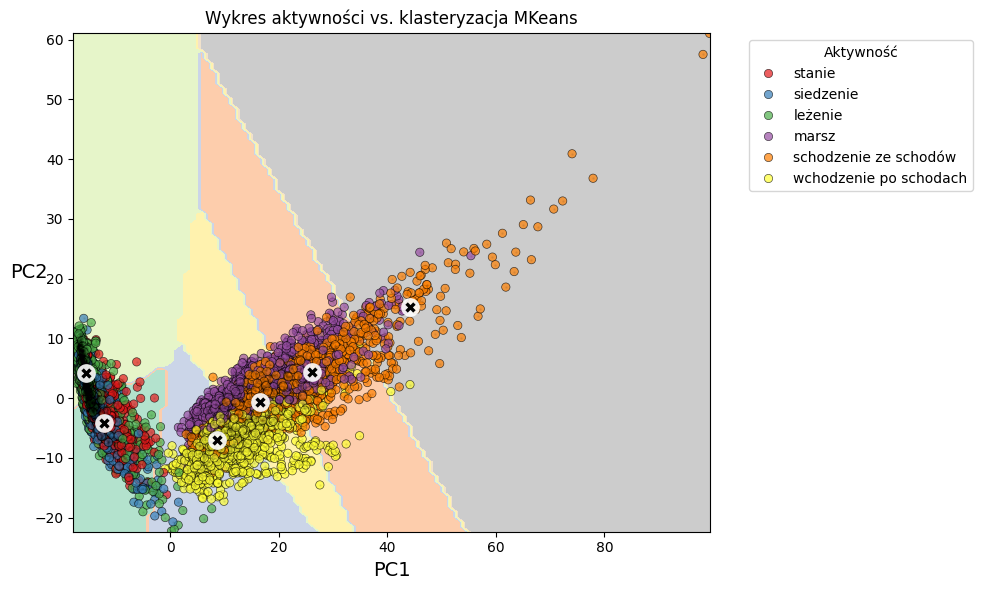

In [13]:
plt.figure(figsize=(10, 6))

plot_decision_boundaries_alpha_005(clf_kmeans, X_pca, show=False)

sns.scatterplot(
    data=df_plot,
    x='PC1', y='PC2',
    hue='activity_label',
    palette='Set1',
    edgecolor='k',
    alpha=0.7
)

plt.title('Wykres aktywności vs. klasteryzacja MKeans')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Aktywność', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**KOMENTARZ: W mojej opinii metoda klasteryzacji KMeans z hiperparametrem n_clusters=6, nie była w stanie prawidłowo określić żadnej z 6 grup aktywności. Analizując powyższy wykres jesteśmy w stanie de facto odróżnić dwie grupy - PIERWSZĄ nazwijmy ją "spoczynkowa" czyli stanie, siedzenie i leżenie, która znajduje się po lewej stronie wykresu oraz DRUGĄ "aktywna" czyli marsz, schodzenie ze schodów, wchodzenie po schodach - znajdująca się po prawej stronie wykresu.**

**Dobieranie prawidłowej ilość klastrów dla KMeans - metodą łokcia (elbow method)**

In [14]:
k_means_per_k=[KMeans(n_clusters=k, random_state=1).fit(X_pca) for k in range(1,10)]
inertias = [model.inertia_ for model in k_means_per_k]

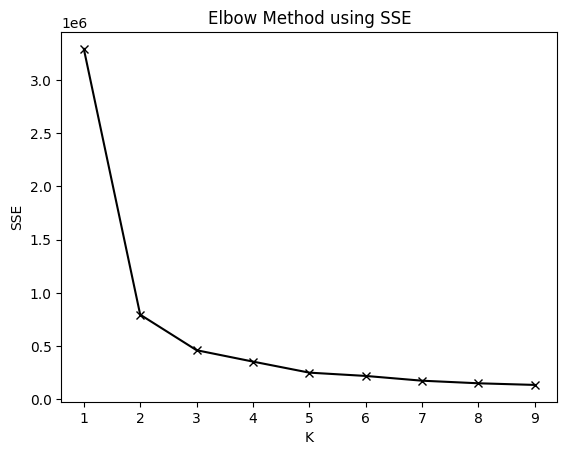

In [15]:
plt.plot(range(1,10), inertias, 'kx-')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title("Elbow Method using SSE")
plt.show()

**[KOMENTARZ] - metoda łokcia (elbow method) dla wyznaczania prawidłowej ilości klastrów określił nam, że prawidłowa ilość klastrów to 3. Po K = 3 nie widać znacznej różnicy w parametrze SSE**

**Użyjmy jeszcze tzn. Silhouette_score do określenia prawidłowej ilości klastrów:**

In [16]:
silhouette_scores = [silhouette_score(X_pca, model.labels_)
                     for model in k_means_per_k[1:]]

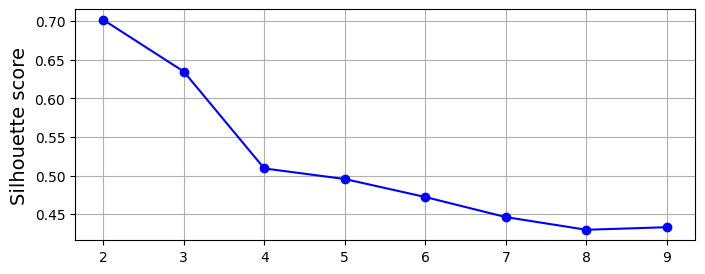

In [17]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.ylabel("Silhouette score", fontsize=14)
plt.grid()
plt.show()

**KOMENTARZ: Prawidłowa ilość klastrów wg Silhouette_score to: 2 - potwierdza ona tezę dwóch grup: "aktywnej" i "spoczynkowej"**

Na danym zbiorze dokonaj preprocessingu, używając metod klasteringu. Następnie wyszkol dwa wybrane przez siebie klasyfikatory typu Supervised Learning i spróbuj uzyskać jak najlepszy wynik, używając wszystkich znanych sobie "wspomagaczy".

In [18]:
X_train_stratify, X_test_stratify, y_train_stratify, y_test_stratify = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=5)

**Tworzymy dwa modelami ML - "logistic regression" oraz "SVC" i trenujemy je bez klasteryzacji - X i y (treningowy i testowy) są już wcześniej zeskalowane oraz podlegały stratyfikacji według y**

In [19]:
LR_model = LogisticRegression(multi_class="ovr", max_iter=10000, random_state=5)
SVC_model = SVC(kernel='rbf', gamma = 'auto', random_state=5)

LR_model.fit(X_train_stratify, y_train_stratify)
SVC_model.fit(X_train_stratify, y_train_stratify)

C:\projects\Wizualizacja_danych_cz1\env\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\projects\Wizualizacja_danych_cz1\env\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\projects\Wizualizacja_danych_cz1\env\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(gamma='auto', random_state=5)

**Tworzymy dwa pipeline z modelami ML - "logistic regression" oraz "SVC" i trenujemy je z preprocesingiem polegającym na klasteryzacją KMeans z hiperparametrem n-clusters=6**

In [20]:
pipeline_LR_kmeans = Pipeline([
    ("kmeans", KMeans(
        n_clusters=6,
        random_state=5
    )),
    ("log_reg", LogisticRegression(
        multi_class="ovr",
        max_iter=10000,
        random_state=5
    ))
])

pipeline_SVC_kmeans = Pipeline([
    ("kmeans", KMeans(
        n_clusters=6,
        random_state=5
    )),
    ("svc", SVC(kernel='rbf', 
        gamma = 'auto',      
        random_state=5
    ))
])   
    
pipeline_LR_kmeans.fit(X_train_stratify, y_train_stratify)
pipeline_SVC_kmeans.fit(X_train_stratify, y_train_stratify)

C:\projects\Wizualizacja_danych_cz1\env\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\projects\Wizualizacja_danych_cz1\env\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\projects\Wizualizacja_danych_cz1\env\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('kmeans', KMeans(n_clusters=6, random_state=5)),
                ('svc', SVC(gamma='auto', random_state=5))])

In [21]:
print('Porównanie wyników modeli LR i SVC na danych testowych\n')
print(f'LR bez klasteryzacji {LR_model.score(X_test_stratify, y_test_stratify):.4f}')
print(f'SVC bez klasteryzacji {SVC_model.score(X_test_stratify, y_test_stratify):.4f}')

print(f'\nLR z klasteryzacji KMeans {pipeline_LR_kmeans.score(X_test_stratify, y_test_stratify):.4f}')
print(f'SVC z klasteryzacji KMeans {pipeline_SVC_kmeans.score(X_test_stratify, y_test_stratify):.4f}')

Porównanie wyników modeli LR i SVC na danych testowych

LR bez klasteryzacji 0.9879
SVC bez klasteryzacji 0.9791

LR z klasteryzacji KMeans 0.7762
SVC z klasteryzacji KMeans 0.7883


**[WNIOSKI] Model LR i SVC uzyskują lepsze wyniki bez klasteryzacji KMeans z hiperparametrem n_clusters=6**

**W związku z tym, że jest to moduł poświęcony klasteryzacji to postaramy się uzyskać możliwie najlepszy wynik dla modelu LR i SVR z użyciem klastryzacji w preprocessingu, użyjemy do tego następujących wspomagaczy: KFold oraz GridSearchCV**

In [22]:
params_lr = {
    'kmeans__n_clusters': [5, 25, 35, 45],
    'log_reg__penalty': ['elasticnet'],
    'log_reg__l1_ratio': [0.2, 0.3, 0.4],
    'log_reg__C': [10, 20, 30],
    'log_reg__solver': ['saga'],
    'log_reg__max_iter': [10000]
}


grid_search_pipeline_LR_kmeans = GridSearchCV(pipeline_LR_kmeans,
                           params_lr,
                           cv=4,
                           n_jobs = -1,
                           verbose = 10,
                           scoring = 'accuracy')

grid_search_pipeline_LR_kmeans.fit(X_train_stratify, y_train_stratify)

print('Wybrane hiperparametry:', grid_search_pipeline_LR_kmeans.best_params_)

model_gridsearch_LR = grid_search_pipeline_LR_kmeans.best_estimator_

print('Wynik model_gridsearch_LR (score):', model_gridsearch_LR.score(X_test_stratify, y_test_stratify))

Fitting 4 folds for each of 36 candidates, totalling 144 fits


C:\projects\Wizualizacja_danych_cz1\env\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\projects\Wizualizacja_danych_cz1\env\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Wybrane hiperparametry: {'kmeans__n_clusters': 45, 'log_reg__C': 10, 'log_reg__l1_ratio': 0.2, 'log_reg__max_iter': 10000, 'log_reg__penalty': 'elasticnet', 'log_reg__solver': 'saga'}
Wynik model_gridsearch_LR (score): 0.9160194174757281


In [23]:
params_svc = {
    'kmeans__n_clusters': [5, 25, 35, 45],
    'svc__kernel': ['rbf', 'linear'],
    'svc__C': [10, 20, 25],
    'svc__gamma': ['scale', 0.005, 0.01, 0.1]
}

grid_search_pipeline_SVC_kmeans = GridSearchCV(
                        pipeline_SVC_kmeans,
                        params_svc,
                        cv=4,
                        n_jobs=-1,
                        verbose=10,
                        scoring='accuracy'
)

grid_search_pipeline_SVC_kmeans.fit(X_train_stratify, y_train_stratify)

print('Wybrane hiperparametry:', grid_search_pipeline_SVC_kmeans.best_params_)

model_gridsearch_SVC = grid_search_pipeline_SVC_kmeans.best_estimator_

print('Wynik model_SVC_GS_v2:', model_gridsearch_SVC.score(X_test_stratify, y_test_stratify))

Fitting 4 folds for each of 96 candidates, totalling 384 fits


C:\projects\Wizualizacja_danych_cz1\env\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Wybrane hiperparametry: {'kmeans__n_clusters': 45, 'svc__C': 25, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Wynik model_SVC_GS_v2: 0.9412621359223301


In [24]:
print('Podsumowanie dla polepszenia wyników dla modeli LR i SVC korzystających z KMeans \n')
print(f'LR z klasteryzacji KMeans (przed ulepszeniami) {pipeline_LR_kmeans.score(X_test_stratify, y_test_stratify):.4f}')
print(f'LR z klasteryzacji KMeans (po ulepszeniach) {model_gridsearch_LR.score(X_test_stratify, y_test_stratify):.4f}\n')
print(f'SVC z klasteryzacji KMeans (przed ulepszeniami) {pipeline_SVC_kmeans.score(X_test_stratify, y_test_stratify):.4f}')
print(f'SVC z klasteryzacji KMeans (po ulepszeniach)  {model_gridsearch_SVC.score(X_test_stratify, y_test_stratify):.4f}')

Podsumowanie dla polepszenia wyników dla modeli LR i SVC korzystających z KMeans 

LR z klasteryzacji KMeans (przed ulepszeniami) 0.7762
LR z klasteryzacji KMeans (po ulepszeniach) 0.9160

SVC z klasteryzacji KMeans (przed ulepszeniami) 0.7883
SVC z klasteryzacji KMeans (po ulepszeniach)  0.9413


**Wnioski:**
Hiperparametr n_cluster w preprocesingu zawierającym metodę klasteryzującą ma spory potencjał do poprawy funkcjonowania w/w modeli ML czyli Logistic Regression i SVC. W naszym przypadku niska wartość w/w hiperparametru powodowała osiąganie słabych wyników, natomiast znaczne jego podniesienie np do wartości 45 znacznie poprawiło osiągany wynik szkolonych modeli.

**Czym różni się KMeans, K-fold i K Nearest Neighbors?**

**[ODPOWIEDź]: Są to trzy różne algorytmy. KMeans to algorytm do klasteryzacji, w którym określamy w hiperparametrze ilość klastrów którą chcielibyśmy, aby model wyszukał. Algorytm działa tylko na zmiennych niezależnych tzn. bez tzn. labels/etykiet i jest modelem uczenia nienadzorowanego. Warto aby dane były zeskalowane. Natomiast K-fold jest to technika walidacji która ocenia skuteczność modelu lepiej niż podział train/test. I ostatnia, czyli KNN to algorytm uczenia nadzorowanego do klasyfikacji lub regresji może słuzyć do klasyfikacji np gatunków kwiatów, predykcji cen lub rozpoznawania obrazów. W każdym z powyższych technik występuje listera "K" gdzie w KMeans to ilość klastrów, K-fold liczna na którą dzielimy zbiór danych i KNN gdzie określa liczba tzw. sąsiadów**